# Barra CNE5 多因子风险模型 — 学习笔记

本 notebook 是 [CAPM.ipynb](CAPM.ipynb) / [fama_french.ipynb](fama_french.ipynb) 的进阶：
CAPM 用 1 个因子、Fama-French 用 3~5 个因子做**定价检验**；
Barra CNE5 用 **10 个风格因子 + 申万行业因子 + 国家因子** 搭建**风险模型**，
目的是预测股票收益的协方差结构、做组合风险归因与优化约束。

**学习路径**：构建 10 风格描述子 → 标准化 → 截面 WLS 求因子收益 → 与米筐官方暴露对照 → 因子协方差与组合风险归因

---

## 一、结构化风险模型方程

截面上，每只股票某期收益被分解为「因子暴露 × 因子收益 + 特质收益」：

$$ r_i = \sum_{k} X_{ik}\, f_k + u_i $$

- $X_{ik}$：股票 $i$ 在因子 $k$ 上的**暴露**（事先可观测，如市值、Beta）
- $f_k$：因子 $k$ 的**收益**（截面回归反解出来的未知数）
- $u_i$：特质收益（无法被因子解释的部分）

每期做一次 $\sqrt{流通市值}$ 加权的 **WLS** 截面回归，得到一组因子收益；时间上滚动即得因子收益序列，
进而估计因子协方差矩阵 $F$，配合特质方差 $\Delta$ 得到股票收益协方差 $\Sigma = X F X^\top + \Delta$。

## 二、CNE5 十个风格因子 ↔ 代码

| 因子 (米筐同名) | 经济含义 | 本笔记主描述子 |
|------|------|----------|
| `size` | 规模 | $\ln(总市值)$ |
| `beta` | 市场敏感度 | 对中证800 的 252 日回归 β |
| `momentum` | 动量 | 过去 252 日剔除最近 21 日的累计对数收益 (RSTR) |
| `residual_volatility` | 残差波动 | 年化日波动(DASTD)，正交化 size、beta |
| `non_linear_size` | 非线性规模 | $size^3$ 正交化 size |
| `book_to_price` | 价值 | $1/PB$ |
| `liquidity` | 流动性 | 月/季/年换手率对数加权 (STOM/STOQ/STOA) |
| `earnings_yield` | 盈利收益 | $1/PE$ (EP) |
| `growth` | 成长 | 净利润+营收+总资产增速 的复合 |
| `leverage` | 杠杆 | 资产负债率 |

## 三、原文与参考资料

- **官方模型文档**：MSCI. *Barra China Equity Model (CNE5).* [MSCI 官方介绍 PDF](https://www.msci.com/documents/10199/242721/Barra_China_Equity_Model_CNE5.pdf/2935796a-0a80-4050-934a-12966d1e2518)（含 10 风格因子 / 21 描述子定义与权重、协方差与特质风险方法）
- **米筐风险因子接口**：[Ricequant 风险因子模块文档](https://www.ricequant.com/doc/rqdata/python/risk-factors-mod.html)（`get_factor_exposure` / `get_factor_return` / `get_factor_covariance` / `get_specific_risk`）

> **数据口径**：股票池=中证800（期初快照）；区间 2021-2024，截面取 2022-2024 各月末交易日
> （需 252 日历史，故截面从 2022 起）；行情/市值/基本面/行业均来自米筐 `rqdatac`。
> 这是**教学简化版**：每个风格用主描述子（CNE5 原版每个因子由多个子描述子加权），
> 国家因子用「行业市值加权平均收益」隐含表示。**注**：CNE5 的 `growth`/`earnings_yield` 还包含
> **分析师预测增长/预期盈利**等前瞻描述子（见上方官方文档），本地数据无法获取，故这两个因子与官方暴露相关性偏低属正常。

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

PROJECT_ROOT = None
for _c in [os.getcwd(), os.path.join(os.getcwd(), '..'), os.path.join(os.getcwd(), '../..')]:
    _r = os.path.abspath(_c)
    if os.path.isdir(os.path.join(_r, 'my_utils')):
        PROJECT_ROOT = _r
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError('未找到项目根目录（需包含 my_utils 文件夹）')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from my_utils.rqdata import RqData
import rqdatac as rq

RqData()
print('米筐初始化完成')

米筐初始化完成


In [2]:
# ===================== Part 1：原始数据准备 =====================
start_date = '2021-01-01'   # 多取一年历史，供 252 日滚动计算
end_date = '2024-12-31'

universe = rq.index_components('000906.XSHG', date=start_date)
print(f'中证800 成分股数: {len(universe)}')

# --- 收盘价：后复权（算收益/动量/Beta） ---
px = rq.get_price(universe, start_date=start_date, end_date=end_date,
                  frequency='1d', fields='close', adjust_type='post')
close = px['close'].unstack('order_book_id').sort_index()

# --- 成交量：原始未复权（算真实换手率，绝不能用复权量！） ---
volp = rq.get_price(universe, start_date=start_date, end_date=end_date,
                    frequency='1d', fields='volume', adjust_type='none')
volume = volp['volume'].unstack('order_book_id').sort_index()

# --- 自由流通股本（算换手率分母） ---
shr = rq.get_shares(universe, start_date=start_date, end_date=end_date, fields='free_circulation')
free_circ = shr['free_circulation'].unstack('order_book_id').reindex(close.index).ffill()

# --- 基本面（日频，缺失日用前值填充） ---
fac = rq.get_factor(universe,
                    ['market_cap_3', 'pb_ratio_ttm', 'pe_ratio_ttm', 'debt_to_asset_ratio_ttm',
                     'net_profit_growth_ratio_ttm', 'operating_revenue_growth_ratio_ttm',
                     'total_asset_growth_ratio_ttm'],
                    start_date=start_date, end_date=end_date)
def _daily(field):
    return fac[field].unstack('order_book_id').reindex(close.index).ffill()
mc_d = _daily('market_cap_3')          # 总市值
pb_d = _daily('pb_ratio_ttm')
pe_d = _daily('pe_ratio_ttm')
lev_d = _daily('debt_to_asset_ratio_ttm')
npg_d = _daily('net_profit_growth_ratio_ttm')          # 净利润增速（成长子项）
rev_d = _daily('operating_revenue_growth_ratio_ttm')   # 营收增速（成长子项）
ag_d = _daily('total_asset_growth_ratio_ttm')          # 总资产增速（成长子项）

# --- 市场组合：中证800 指数 ---
idx = rq.get_price('000906.XSHG', start_date=start_date, end_date=end_date,
                   frequency='1d', fields='close')
idx_close = idx['close'].droplevel('order_book_id').reindex(close.index)

print(f'交易日数: {len(close)}, 股票数: {close.shape[1]}')
print(f'区间: {close.index.min():%Y-%m-%d} ~ {close.index.max():%Y-%m-%d}')

中证800 成分股数: 800


交易日数: 969, 股票数: 800
区间: 2021-01-04 ~ 2024-12-31


In [3]:
# ===================== Part 2：构建风格描述子（向量化滚动计算） =====================
WIN = 252  # 滚动窗口（约一年）

ret = close.pct_change()                       # 日简单收益
logret = np.log(close / close.shift(1))        # 日对数收益
rm = idx_close.pct_change()                    # 市场日收益

# --- Beta 与残差波动：用滚动一阶/二阶矩显式计算（教学透明） ---
mean_i = ret.rolling(WIN).mean()
mean_m = rm.rolling(WIN).mean()
cov_im = ret.mul(rm, axis=0).rolling(WIN).mean().sub(mean_i.mul(mean_m, axis=0))
var_m = (rm ** 2).rolling(WIN).mean() - mean_m ** 2
beta_d = cov_im.div(var_m, axis=0)             # β = Cov(r_i, r_m)/Var(r_m)

var_i = (ret ** 2).rolling(WIN).mean() - mean_i ** 2
dastd_d = np.sqrt(var_i.clip(lower=0)) * np.sqrt(252)   # 年化日波动(DASTD)，作残差波动主描述子

# --- 动量 RSTR：剔除最近 21 日，累计过去对数收益 ---
rstr_d = logret.shift(21).rolling(WIN - 21).sum()

# --- 流动性：日换手率的月/季/年对数（STOM/STOQ/STOA 加权） ---
turn = (volume / free_circ).replace([np.inf, -np.inf], np.nan)
stom = np.log(turn.rolling(21).sum().replace(0, np.nan))
stoq = np.log((turn.rolling(63).sum() / 3).replace(0, np.nan))
stoa = np.log((turn.rolling(252).sum() / 12).replace(0, np.nan))
liq_d = 0.35 * stom + 0.35 * stoq + 0.30 * stoa

# --- 直接来自基本面的描述子 ---
size_d = np.log(mc_d)                           # 规模
bp_d = (1.0 / pb_d).where(pb_d > 0)             # 账面市值比
ep_d = 1.0 / pe_d.where(pe_d != 0)              # 盈利收益（PE<0 时 EP<0，去极值阶段处理）

# 截面日期：2022-2024 各月最后一个交易日（前置 252 日历史已就绪）
month_last = close.index.to_series().resample('M').last()
cs_dates = [d for d in month_last if d >= pd.Timestamp('2022-01-01')]
print(f'截面期数: {len(cs_dates)}（{cs_dates[0]:%Y-%m} ~ {cs_dates[-1]:%Y-%m}）')

# 行业：用最后一个截面日的申万一级行业（行业成分变动慢，教学用固定映射）
sw = rq.shenwan_instrument_industry(universe, date=str(cs_dates[-1].date()))
industry_map = sw['index_name'].reindex(close.columns).fillna('未知')
print(f'行业数: {industry_map.nunique()}')

截面期数: 36（2022-01 ~ 2024-12）
行业数: 32


In [4]:
# ===================== Part 3：标准化与暴露矩阵 =====================
# 标准化三步：①行业中位数填缺 ②MAD 去极值 ③市值加权 z-score（均值0、标准差1）
STYLES = ['size', 'beta', 'momentum', 'residual_volatility', 'non_linear_size',
          'book_to_price', 'liquidity', 'earnings_yield', 'growth', 'leverage']


def winsorize_mad(s, n=3.0):
    med = s.median()
    mad = (s - med).abs().median() * 1.4826      # 1.4826 使 MAD 近似标准差
    if not np.isfinite(mad) or mad == 0:
        return s
    return s.clip(med - n * mad, med + n * mad)


def standardize(s, ind, mcap):
    s = s.copy()
    s = s.fillna(s.groupby(ind).transform('median')).fillna(s.median())  # 行业中位数填缺
    s = winsorize_mad(s)                                                 # 去极值
    w = mcap / mcap.sum()
    mu = float((s * w).sum())                                            # 市值加权均值
    sd = s.std(ddof=0)
    return (s - mu) / sd if sd and np.isfinite(sd) else s * 0.0


def build_exposures(d):
    """构建第 d 期全部股票的 10 个标准化风格暴露。"""
    raw = pd.DataFrame({
        'size': size_d.loc[d], 'beta': beta_d.loc[d], 'momentum': rstr_d.loc[d],
        'residual_volatility': dastd_d.loc[d], 'book_to_price': bp_d.loc[d],
        'liquidity': liq_d.loc[d], 'earnings_yield': ep_d.loc[d], 'leverage': lev_d.loc[d],
    })
    mcap = mc_d.loc[d].reindex(raw.index)
    ind = industry_map.reindex(raw.index).fillna('未知')
    keep = mcap.notna() & (mcap > 0)            # 剔除停牌/退市（无市值）
    raw, mcap, ind = raw[keep], mcap[keep], ind[keep]

    z = pd.DataFrame({c: standardize(raw[c], ind, mcap) for c in raw.columns})
    # 非线性规模：size 的三次方对 size 正交化后再标准化
    s = z['size']
    coef = np.polyfit(s, s ** 3, 1)
    nl = s ** 3 - (coef[0] * s + coef[1])
    z['non_linear_size'] = standardize(pd.Series(nl, index=s.index), ind, mcap)
    # 残差波动：剔除与 size、beta 的共线性（回归取残差）
    resid = sm.OLS(z['residual_volatility'], sm.add_constant(z[['size', 'beta']])).fit().resid
    z['residual_volatility'] = standardize(pd.Series(resid, index=z.index), ind, mcap)
    # 成长：实现增长复合（净利润+营收+总资产增速）标准化后等权平均，再标准化
    g = (standardize(npg_d.loc[d].reindex(raw.index), ind, mcap)
         + standardize(rev_d.loc[d].reindex(raw.index), ind, mcap)
         + standardize(ag_d.loc[d].reindex(raw.index), ind, mcap)) / 3.0
    z['growth'] = standardize(g, ind, mcap)
    return z[STYLES], mcap, ind


# 演示：最后一个截面日的暴露统计（市值加权均值≈0、标准差≈1）
Z_demo, mcap_demo, ind_demo = build_exposures(cs_dates[-1])
print(f'=== {cs_dates[-1]:%Y-%m-%d} 截面：{len(Z_demo)} 只股票，10 风格暴露 ===')
print(Z_demo.describe().loc[['mean', 'std', 'min', 'max']].round(3).to_string())

=== 2024-12-31 截面：800 只股票，10 风格暴露 ===
       size   beta  momentum  residual_volatility  non_linear_size  book_to_price  liquidity  earnings_yield  growth  leverage
mean -1.466  0.711    -0.494               -0.188            1.036         -0.152      0.714          -0.712  -0.399    -0.435
std   1.001  1.001     1.001                1.001            1.001          1.001      1.001           1.001   1.001     1.001
min  -4.170 -1.932    -3.279               -2.243           -0.702         -1.562     -1.924          -2.875  -2.930    -2.588
max   0.967  3.386     2.267                2.293            2.010          2.107      3.117           1.465   2.353     2.752


=== 因子收益序列：35 期 × 11 因子 ===
                     月均收益%     t值
size                -0.073 -0.333
beta                -0.249 -0.869
momentum             0.113  0.441
residual_volatility -0.307 -1.449
non_linear_size     -0.077 -0.625
book_to_price        0.194  1.044
liquidity            0.057  0.382
earnings_yield       0.228  1.181
growth              -0.194 -1.503
leverage             0.036  0.318
country              0.341  0.389


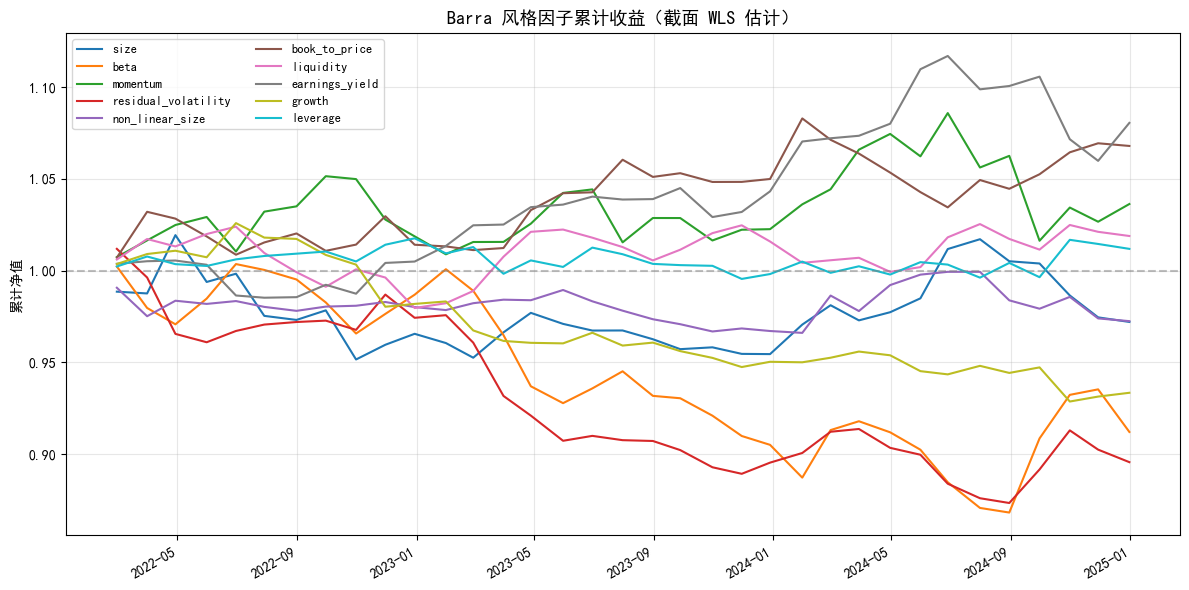

In [5]:
# ===================== Part 4：截面 WLS 回归求因子收益 =====================
# 设计矩阵 X = [申万行业哑变量(无截距) | 10 风格因子]，权重 W = sqrt(流通市值)。
# 行业哑变量系数=各行业因子收益；国家(市场)因子收益=行业收益的市值加权平均；
# 残差=特质收益 u_i（Part 6 用它估特质风险）。

def cs_factor_returns(d, fwd_ret):
    Z, mcap, ind = build_exposures(d)
    df = Z.copy()
    df['ret'] = fwd_ret.reindex(Z.index)
    df['ind'] = ind
    df['w'] = np.sqrt(mcap)
    df = df.dropna()
    if len(df) < 100:
        return None
    D = pd.get_dummies(df['ind']).astype(float)        # 行业哑变量
    X = pd.concat([D, df[STYLES]], axis=1).astype(float)
    w = df['w'].values
    XtW = X.T.values * w                                # X' W
    coef = np.linalg.solve(XtW @ X.values, XtW @ df['ret'].values)
    fr = pd.Series(coef, index=X.columns)
    resid = pd.Series(df['ret'].values - X.values @ coef, index=df.index)   # 特质收益
    # 国家因子：行业因子收益的市值加权平均（w^2 = 流通市值）
    ind_cap = df.groupby('ind')['w'].apply(lambda x: (x ** 2).sum())
    ind_cap = ind_cap / ind_cap.sum()
    out = fr[STYLES].copy()
    out['country'] = float((fr[D.columns] * ind_cap.reindex(D.columns)).sum())
    return out, resid


# 逐期回归：第 t 期暴露 → 第 t 到 t+1 期收益
style_returns, spec_returns = {}, {}
for k in range(len(cs_dates) - 1):
    d, d1 = cs_dates[k], cs_dates[k + 1]
    fwd = close.loc[d1] / close.loc[d] - 1
    res = cs_factor_returns(d, fwd)
    if res is not None:
        style_returns[d1], spec_returns[d1] = res
SR = pd.DataFrame(style_returns).T                       # 因子收益序列
spec_ret = pd.DataFrame(spec_returns).T                  # 特质收益序列（期×股票）
print(f'=== 因子收益序列：{SR.shape[0]} 期 × {SR.shape[1]} 因子 ===')
tstat = SR.mean() / (SR.std(ddof=1) / np.sqrt(len(SR)))
print(pd.DataFrame({'月均收益%': SR.mean() * 100, 't值': tstat}).round(3).to_string())

fig, ax = plt.subplots(figsize=(12, 6))
(1 + SR[STYLES]).cumprod().plot(ax=ax, linewidth=1.5)
ax.axhline(1, color='gray', ls='--', alpha=0.5)
ax.set_title('Barra 风格因子累计收益（截面 WLS 估计）', fontsize=13)
ax.set_ylabel('累计净值'); ax.grid(True, alpha=0.3); ax.legend(ncol=2, fontsize=9)
plt.tight_layout(); plt.show()

=== 2024-12-31 自建暴露 vs 米筐官方暴露 横截面相关性 ===
size                   0.975
beta                   0.960
momentum               0.793
residual_volatility    0.815
non_linear_size        0.570
book_to_price          0.916
liquidity              0.827
earnings_yield         0.775
growth                 0.369
leverage               0.788

平均 |相关性| = 0.779
解读：多数因子相关性高(>0.75)、方向正确，说明构建口径合理；growth 最低(~0.37)——官方 CNE5 成长因子含分析师预测增长描述子，本地仅用历史实现增长；non_linear_size 为派生因子、相关性次之；均属口径差异而非错误。


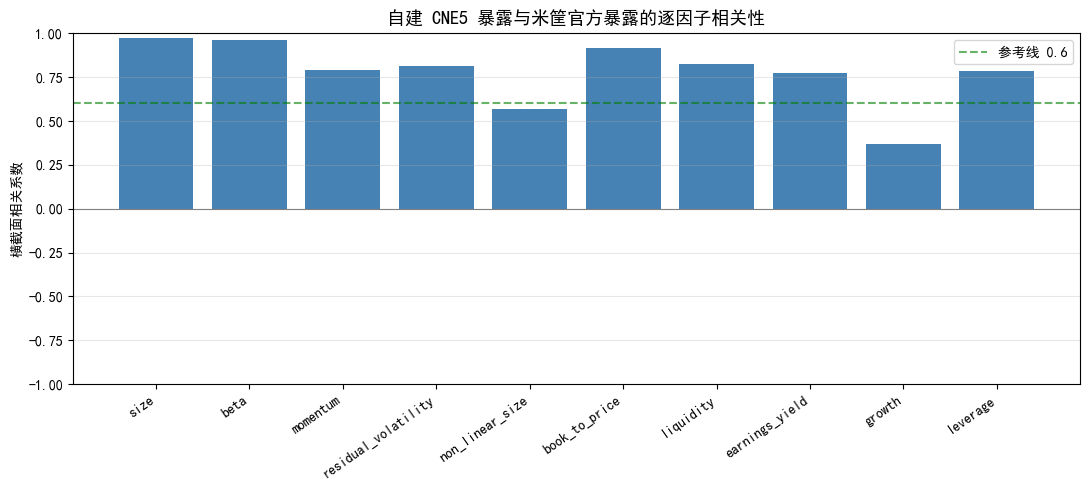

In [6]:
# ===================== Part 5：与米筐官方因子暴露对照验证 =====================
# 米筐 get_factor_exposure 直接给出官方 CNE 风格暴露，列名与本笔记一致。
# 用同一截面日，逐因子计算「自建暴露 vs 官方暴露」的横截面相关系数，验证构建方向是否正确。
d0 = cs_dates[-1]
Z_self, _, _ = build_exposures(d0)

off = rq.get_factor_exposure(universe, start_date=str(d0.date()), end_date=str(d0.date()))
if isinstance(off.index, pd.MultiIndex):
    off = off.droplevel('date') if 'date' in off.index.names else off.reset_index(level=-1, drop=True)
off = off[[c for c in STYLES if c in off.columns]]

corr = pd.Series({c: Z_self[c].corr(off[c].reindex(Z_self.index)) for c in STYLES if c in off.columns})
print(f'=== {d0:%Y-%m-%d} 自建暴露 vs 米筐官方暴露 横截面相关性 ===')
print(corr.round(3).to_string())
print(f'\n平均 |相关性| = {corr.abs().mean():.3f}')
print('解读：多数因子相关性高(>0.75)、方向正确，说明构建口径合理；'
      'growth 最低(~0.37)——官方 CNE5 成长因子含分析师预测增长描述子，本地仅用历史实现增长；'
      'non_linear_size 为派生因子、相关性次之；均属口径差异而非错误。')

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['steelblue' if v >= 0 else 'coral' for v in corr.values]
ax.bar(range(len(corr)), corr.values, color=colors)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.index, rotation=35, ha='right')
ax.axhline(0, color='gray', lw=0.8)
ax.axhline(0.6, color='green', ls='--', alpha=0.6, label='参考线 0.6')
ax.set_ylabel('横截面相关系数'); ax.set_ylim(-1, 1)
ax.set_title('自建 CNE5 暴露与米筐官方暴露的逐因子相关性', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

=== 风格因子年化波动 ===
size                   0.0448
beta                   0.0586
momentum               0.0526
residual_volatility    0.0433
non_linear_size        0.0253
book_to_price          0.0380
liquidity              0.0307
earnings_yield         0.0395
growth                 0.0264
leverage               0.0231

特质年化波动：中位数 0.2323，均值 0.2596
注：米筐亦提供 get_factor_covariance / get_specific_risk，可与自建结果对照。


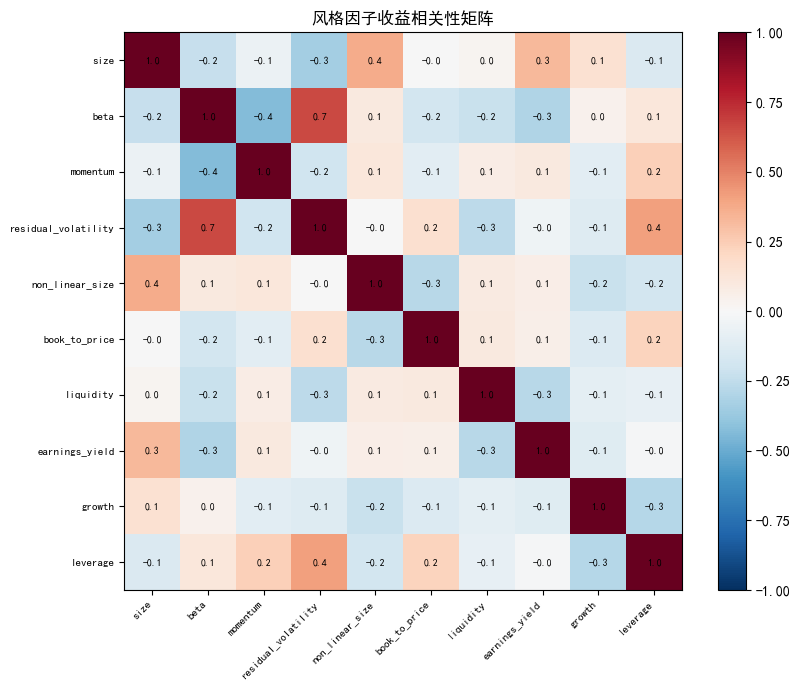

In [7]:
# ===================== Part 6：因子协方差矩阵与特质风险 =====================
# 风险模型核心：股票收益协方差 Σ = X F Xᵀ + Δ
#   F = 因子收益协方差（由因子收益序列估计）；Δ = 特质方差对角阵（由截面回归残差估计）
F_cov = SR[STYLES].cov() * 12                  # 月频因子收益 → 年化因子协方差
F_corr = SR[STYLES].corr()
fac_vol = pd.Series(np.sqrt(np.diag(F_cov)), index=STYLES)   # 各因子年化波动
spec_vol = spec_ret.std(ddof=1) * np.sqrt(12)               # 各股特质年化波动

print('=== 风格因子年化波动 ===')
print(fac_vol.round(4).to_string())
print(f'\n特质年化波动：中位数 {spec_vol.median():.4f}，均值 {spec_vol.mean():.4f}')
print('注：米筐亦提供 get_factor_covariance / get_specific_risk，可与自建结果对照。')

fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(F_corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(STYLES))); ax.set_xticklabels(STYLES, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(STYLES))); ax.set_yticklabels(STYLES, fontsize=8)
for i in range(len(STYLES)):
    for j in range(len(STYLES)):
        ax.text(j, i, f'{F_corr.iloc[i, j]:.1f}', ha='center', va='center', fontsize=7)
ax.set_title('风格因子收益相关性矩阵', fontsize=12)
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

=== 等权组合年化风险归因 ===
组合风格暴露:
size                  -1.466
beta                   0.711
momentum              -0.494
residual_volatility   -0.188
non_linear_size        1.036
book_to_price         -0.152
liquidity              0.714
earnings_yield        -0.712
growth                -0.399
leverage              -0.435

组合年化波动 = 0.1058  （因子部分 0.1052 / 特质部分 0.0105）
因子风险占总方差 99.0%，特质风险占 1.0%
解读：① 等权组合相对市值加权基准超配小盘，故 size 暴露为负、对组合风险贡献显著；② 单个因子方差贡献可正可负（含与其他因子的协方差交叉项），合计=因子风险方差；③ 特质风险被 ~800 只股票分散到极低（1/N 效应），而因子风险无法分散——这正是 Barra 风险模型的核心洞见：组合风险主要来自因子暴露。


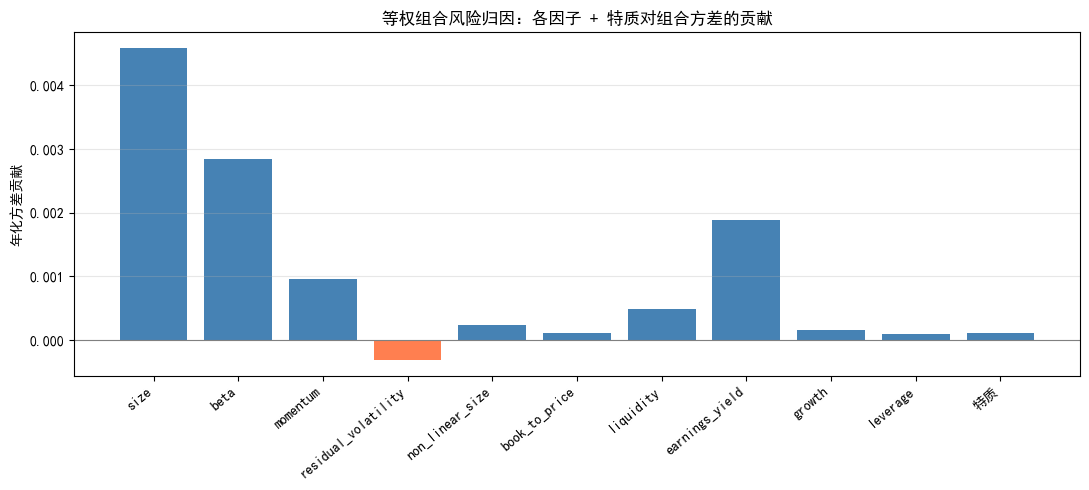

In [8]:
# ===================== Part 7：示例组合的风险归因 =====================
# 用因子模型把组合风险拆成「各因子贡献 + 特质贡献」。示例用等权组合。
d0 = cs_dates[-1]
X0, mcap0, ind0 = build_exposures(d0)
w = pd.Series(1.0 / len(X0), index=X0.index)             # 等权示例组合

x_style = X0.mul(w, axis=0).sum()                         # 组合风格暴露 (10,)
F = F_cov.values
factor_var = float(x_style.values @ F @ x_style.values)  # 因子风险方差
contrib = pd.Series(x_style.values * (F @ x_style.values), index=STYLES)  # 各因子方差贡献(和=factor_var)
s2 = spec_vol.reindex(X0.index).fillna(spec_vol.median()) ** 2
spec_var = float(((w ** 2) * s2).sum())                  # 特质风险方差
total_var = factor_var + spec_var

print('=== 等权组合年化风险归因 ===')
print('组合风格暴露:'); print(x_style.round(3).to_string())
print(f'\n组合年化波动 = {np.sqrt(total_var):.4f}'
      f'  （因子部分 {np.sqrt(factor_var):.4f} / 特质部分 {np.sqrt(spec_var):.4f}）')
print(f'因子风险占总方差 {factor_var / total_var:.1%}，特质风险占 {spec_var / total_var:.1%}')
print('解读：① 等权组合相对市值加权基准超配小盘，故 size 暴露为负、对组合风险贡献显著；'
      '② 单个因子方差贡献可正可负（含与其他因子的协方差交叉项），合计=因子风险方差；'
      f'③ 特质风险被 ~{len(X0)} 只股票分散到极低（1/N 效应），而因子风险无法分散'
      '——这正是 Barra 风险模型的核心洞见：组合风险主要来自因子暴露。')

parts = contrib.copy()
parts['特质'] = spec_var
fig, ax = plt.subplots(figsize=(11, 5))
colors = ['steelblue' if v >= 0 else 'coral' for v in parts.values]
ax.bar(range(len(parts)), parts.values, color=colors)
ax.set_xticks(range(len(parts))); ax.set_xticklabels(parts.index, rotation=40, ha='right')
ax.axhline(0, color='gray', lw=0.8)
ax.set_ylabel('年化方差贡献')
ax.set_title('等权组合风险归因：各因子 + 特质对组合方差的贡献', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

## 四、学习小结

1. **描述子构建（Part 2）**：10 风格因子来自三类原料——价格序列（beta/动量/残差波动/流动性）、市值（规模/非线性规模）、基本面（价值/盈利/成长/杠杆）。滚动计算全部向量化。**注意**：换手率必须用**未复权成交量**，若误用后复权量会让流动性因子严重失真。
2. **标准化（Part 3）**：行业中位数填缺 → MAD 去极值 → 市值加权 z-score；非线性规模、残差波动还做正交化剔除共线性。
3. **截面回归（Part 4）**：每期用 $\sqrt{流通市值}$ 加权 WLS，把个股收益回归到「行业哑变量 + 风格暴露」，反解因子收益与特质收益。
4. **验证（Part 5）**：与米筐官方 `get_factor_exposure` 逐因子求相关性。多数因子相关性高（方向正确）；`growth` 因官方含分析师预测增长描述子、本地仅用历史实现增长而相关性偏低（口径差异，非错误）。
5. **风险模型（Part 6-7）**：用因子收益序列估因子协方差 $F$、用残差估特质风险，组成 $\Sigma = X F X^\top + \Delta$；并以等权组合演示**风险归因**——把组合波动拆解到各风格因子与特质成分，直观看到「特质风险可被分散、因子风险不可分散」。

**Barra 的用途**：① 估计稳健的股票收益**协方差矩阵**；② 组合**风险归因**；③ 组合优化中的**风险约束**（控制风格/行业暴露）。

**与 Fama-French 的本质区别**：FF 是**定价检验**（少数可交易因子组合，问"能否解释收益"）；Barra 是**风险模型**（数十个因子，问"收益如何协同波动"），目标与构造方式都不同。